<a href="https://colab.research.google.com/github/piush365/PromptOpt/blob/main/Code_Alpaca_Cleaned_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q datasets pandas numpy matplotlib seaborn nltk wordcloud

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

In [ ]:
ds = load_dataset("sahil2801/CodeAlpaca-20k")
print(ds)

df = ds["train"].to_pandas()
print(df.shape)
df.head()

README.md:   0%|          | 0.00/147 [00:00<?, ?B/s]

code_alpaca_20k.json:   0%|          | 0.00/8.06M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20022 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['output', 'instruction', 'input'],
        num_rows: 20022
    })
})
(20022, 3)


,output,instruction,input
0,"arr = [2, 4, 6, 8, 10]",Create an array of length 5 which contains all even numbers between 1 and 10.,
1,Height of triangle = opposite side length * sin (angle) / side length,"Formulate an equation to calculate the height of a triangle given the angle, side lengths and opposite side length.",
2,"def replace(self, replace_with):\n new_string = """"\n for char in self:\n if char == "" "":\n n...",Write a replace method for a string class which replaces the given string with a given set of characters.,"string = ""Hello World!""\nreplace_with = ""Greetings!"""
3,"arr = [3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45]",Create an array of length 15 containing numbers divisible by 3 up to 45.,
4,"def find_num_distinct_states(matrix):\n states = set()\n for row in matrix:\n state = """".join([str(x) f...",Write a function to find the number of distinct states in a given matrix.,"matrix = [[1, 0, 0],\n [1, 0, 1],\n [1, 1, 1]]"


In [ ]:
print("Columns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nNull counts:\n", df.isnull().sum())
print("\nEmpty-string counts:")
for col in ["instruction", "input", "output"]:
    print(f"  {col}: {(df[col].astype(str).str.strip() == '').sum()}")

Columns: ['output', 'instruction', 'input']

Dtypes:
 output         object
instruction    object
input          object
dtype: object

Null counts:
 output         0
instruction    0
input          0
dtype: int64

Empty-string counts:
  instruction: 0
  input: 9764
  output: 6


In [ ]:
dup_instruction = df["instruction"].duplicated().sum()
dup_full_row = df.duplicated(subset=["instruction", "input", "output"]).sum()
print(f"Duplicate instructions (ignoring input/output): {dup_instruction}")
print(f"Fully duplicate rows: {dup_full_row}")

# near-duplicate check via normalized text (case/whitespace-insensitive)
norm = df["instruction"].str.lower().str.strip().str.replace(r"\s+", " ", regex=True)
print(f"Duplicate instructions after normalization: {norm.duplicated().sum()}")

Duplicate instructions (ignoring input/output): 0
Fully duplicate rows: 0
Duplicate instructions after normalization: 0


In [ ]:
df["has_input"] = df["input"].astype(str).str.strip().ne("")
print(df["has_input"].value_counts())
print(f"% with input/context: {df['has_input'].mean()*100:.2f}%")

has_input
True     10258
False     9764
Name: count, dtype: int64
% with input/context: 51.23%


In [ ]:
def word_count(s):
    return len(str(s).split())

def char_count(s):
    return len(str(s))

for col in ["instruction", "input", "output"]:
    df[f"{col}_words"] = df[col].apply(word_count)
    df[f"{col}_chars"] = df[col].apply(char_count)

length_summary = df[[f"{c}_words" for c in ["instruction", "input", "output"]] +
                     [f"{c}_chars" for c in ["instruction", "input", "output"]]].describe(
    percentiles=[.05, .25, .5, .75, .9, .95, .99]
)
print(length_summary)

       instruction_words   input_words  output_words  instruction_chars  \
count       20022.000000  20022.000000  20022.000000        20022.00000   
mean           13.415543      4.115173     26.398412           73.75487   
std             4.478769      6.358818     27.347261           23.95251   
min             4.000000      0.000000      0.000000           14.00000   
5%              7.000000      0.000000      3.000000           41.00000   
25%            10.000000      0.000000      9.000000           57.00000   
50%            13.000000      1.000000     17.000000           71.00000   
75%            16.000000      6.000000     35.000000           86.00000   
90%            19.000000     11.000000     61.000000          104.00000   
95%            21.000000     15.000000     79.000000          117.00000   
99%            27.000000     28.000000    124.790000          148.00000   
max            52.000000     98.000000    479.000000          288.00000   

        input_chars  out

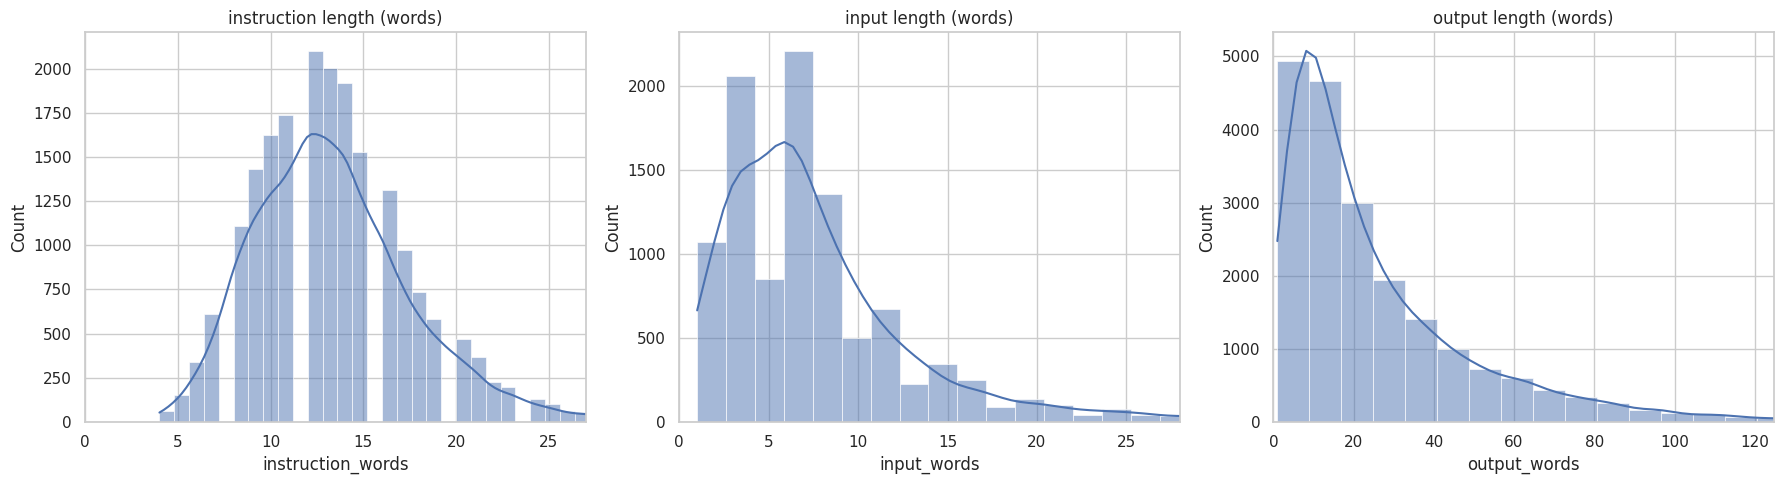

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["instruction", "input", "output"]):
    sns.histplot(df[df[f"{col}_words"] > 0][f"{col}_words"], bins=60, ax=ax, kde=True)
    ax.set_title(f"{col} length (words)")
    ax.set_xlim(0, df[f"{col}_words"].quantile(0.99))
plt.tight_layout()
plt.savefig("alpaca_length_histograms.png", dpi=150)
plt.show()

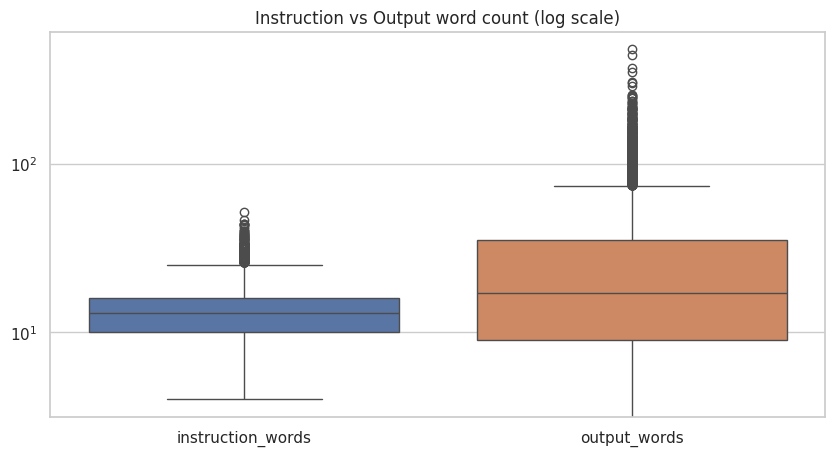

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df[["instruction_words", "output_words"]], ax=ax)
ax.set_yscale("log")
ax.set_title("Instruction vs Output word count (log scale)")
plt.savefig("alpaca_boxplot.png", dpi=150)
plt.show()

In [ ]:
empty_outputs = (df["output"].astype(str).str.strip() == "").sum()
very_short_outputs = (df["output_words"] <= 2).sum()
print(f"Empty outputs: {empty_outputs}")
print(f"Outputs with <=2 words: {very_short_outputs}")
df[df["output_words"] <= 2][["instruction", "output"]].head(10)

Empty outputs: 6
Outputs with <=2 words: 998


,instruction,output
73,Generate a regular expression to match a valid email address.,"/^([a-zA-Z0-9_\-\.]+)@([a-zA-Z0-9_\-\.]+)\.([a-zA-Z]{2,5})$/"
172,Create a new button using HTML.,<button>My Button</button>
193,"Create a Regular Expression pattern to find words that contain the letters ""a"", ""b"", and ""c"".",\b[abc]+\w*\b
225,Classify the following sentence as positive or negative sentiment.,Negative sentiment.
230,Classify the following sentence as a question or a statement.,Question.
251,Change the following array so that it orders in ascending order,array.sort()
256,Write a code to return the first 3 elements in a list.,mylist[:3]
265,Estimate the time complexity of the following algorithm.,O(n^2)
287,Write an HTML code to create a horizontal line.,<hr>
299,Calculate the sum of an array of integers,24


% instructions with an explicit format request: 19.24%

Breakdown by format type:
 list         2427
table        1120
json          289
paragraph      64
steps          16
numbered        9
bullets         4
Name: count, dtype: int64


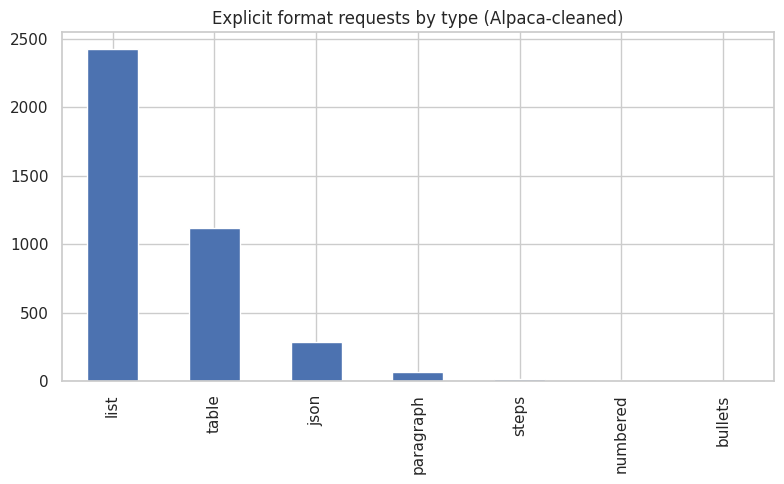

In [ ]:
FORMAT_PATTERNS = {
    "list": r"\blist\b|\benumerate\b",
    "table": r"\btable\b|\bmarkdown table\b",
    "json": r"\bjson\b",
    "bullets": r"\bbullet(s)?\b|\bbulleted\b",
    "paragraph": r"\bparagraph\b|\bessay\b",
    "steps": r"\bstep(s)?\b|\bstep[- ]by[- ]step\b",
    "numbered": r"\bnumbered\b|\b\d+\.\s",
}

def detect_formats(text):
    text = str(text).lower()
    hits = [name for name, pat in FORMAT_PATTERNS.items() if re.search(pat, text)]
    return hits

df["requested_formats"] = df["instruction"].apply(detect_formats)
df["has_format_request"] = df["requested_formats"].apply(len).gt(0)

print(f"% instructions with an explicit format request: {df['has_format_request'].mean()*100:.2f}%")

format_counts = pd.Series(
    [fmt for fmts in df["requested_formats"] for fmt in fmts]
).value_counts()
print("\nBreakdown by format type:\n", format_counts)

fig, ax = plt.subplots(figsize=(8, 5))
format_counts.plot(kind="bar", ax=ax)
ax.set_title("Explicit format requests by type (Alpaca-cleaned)")
plt.tight_layout()
plt.savefig("alpaca_format_types.png", dpi=150)
plt.show()

instruction_first_word
create       4509
write        4483
generate      856
construct     619
given         595
design        555
how           527
what          511
using         434
edit          381
implement     329
suggest       320
find          310
develop       272
convert       265
explain       256
use           219
modify        209
you           199
rewrite       169
calculate     161
describe      156
identify      130
change        121
compute       109
Name: count, dtype: int64


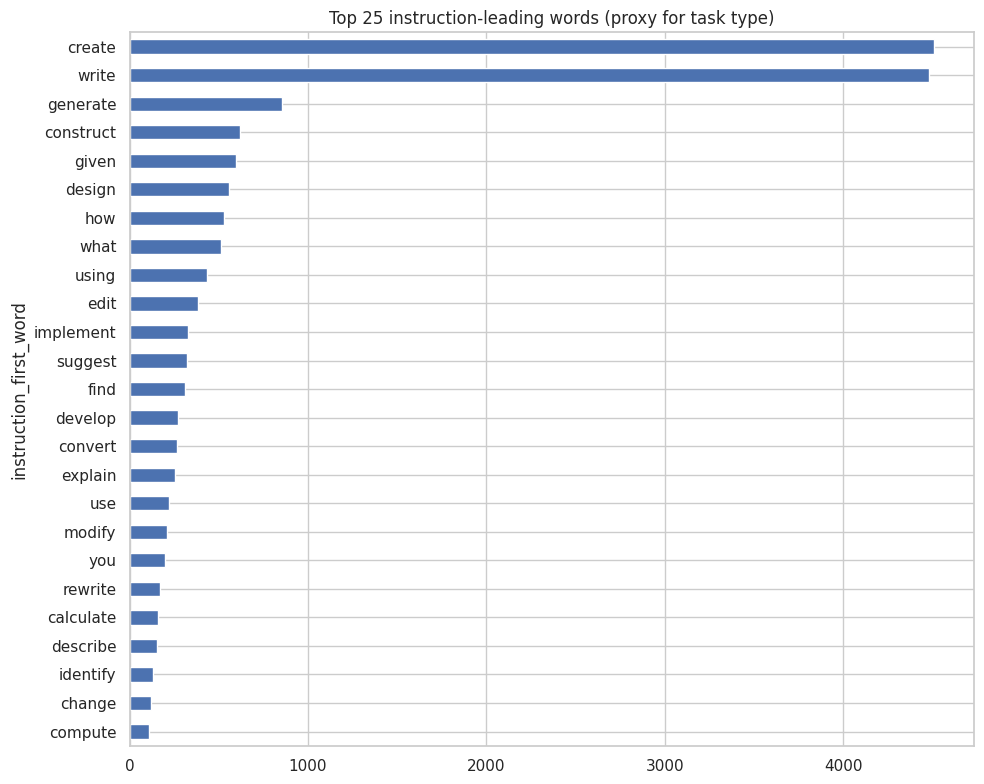

In [ ]:
def first_word(s):
    words = str(s).strip().split()
    return words[0].lower() if words else ""

df["instruction_first_word"] = df["instruction"].apply(first_word)
top_verbs = df["instruction_first_word"].value_counts().head(25)
print(top_verbs)

fig, ax = plt.subplots(figsize=(10, 8))
top_verbs.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("Top 25 instruction-leading words (proxy for task type)")
plt.tight_layout()
plt.savefig("alpaca_top_verbs.png", dpi=150)
plt.show()

Pearson correlation (instruction_words vs output_words): -0.046


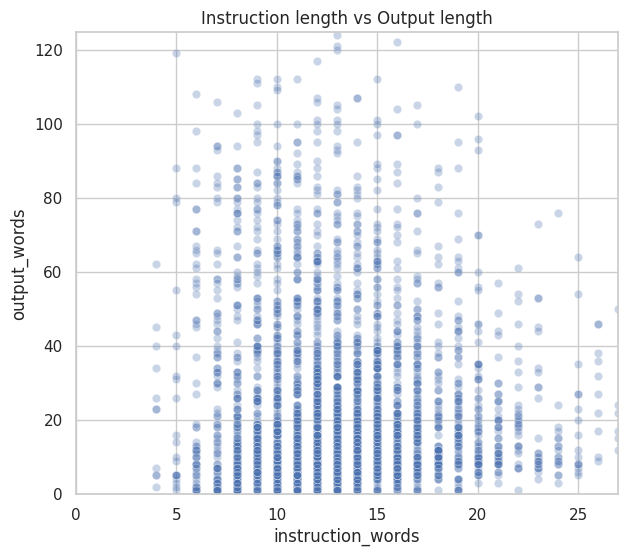

In [ ]:
corr = df["instruction_words"].corr(df["output_words"])
print(f"Pearson correlation (instruction_words vs output_words): {corr:.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=df.sample(min(3000, len(df)), random_state=42),
                 x="instruction_words", y="output_words", alpha=0.3, ax=ax)
ax.set_xlim(0, df["instruction_words"].quantile(0.99))
ax.set_ylim(0, df["output_words"].quantile(0.99))
ax.set_title("Instruction length vs Output length")
plt.savefig("alpaca_scatter.png", dpi=150)
plt.show()

In [ ]:
print(df.groupby("has_input")["output_words"].describe())

             count       mean       std  min  25%   50%   75%    max
has_input                                                           
False       9764.0  28.890926  30.19571  0.0  9.0  18.0  39.0  479.0
True       10258.0  24.025931  24.09125  0.0  9.0  17.0  31.0  305.0


In [ ]:
from collections import Counter
import itertools

def top_ngrams(series, n=2, top_k=20):
    tokens = series.astype(str).str.lower().str.findall(r"[a-z']+")
    grams = itertools.chain.from_iterable(
        zip(*[tok[i:] for i in range(n)]) for tok in tokens
    )
    return Counter(" ".join(g) for g in grams).most_common(top_k)

print("Top instruction bigrams:")
for gram, count in top_ngrams(df["instruction"], n=2):
    print(f"  {gram}: {count}")


Top instruction bigrams:
  create a: 4316
  write a: 4200
  a given: 2377
  the following: 2249
  a function: 2073
  code to: 1612
  of the: 1535
  an array: 1428
  in a: 1421
  in the: 1384
  the given: 1312
  of a: 1280
  a list: 1218
  query to: 1181
  in python: 1169
  function to: 1155
  find the: 1150
  sql query: 1148
  program to: 1139
  list of: 1076


In [ ]:
EMAIL_RE = r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}"
PHONE_RE = r"\b\d{3}[-.\s]??\d{3}[-.\s]??\d{4}\b"

def contains_pii(text):
    text = str(text)
    return bool(re.search(EMAIL_RE, text) or re.search(PHONE_RE, text))

df["has_pii"] = (df["instruction"] + " " + df["input"] + " " + df["output"]).apply(contains_pii)
print(f"Rows with likely email/phone PII: {df['has_pii'].sum()}")

Rows with likely email/phone PII: 129


In [ ]:
summary = {
    "total_rows": len(df),
    "fully_duplicate_rows": int(dup_full_row),
    "duplicate_instructions": int(dup_instruction),
    "pct_with_input": round(df["has_input"].mean() * 100, 2),
    "pct_empty_output": round(empty_outputs / len(df) * 100, 4),
    "pct_format_request": round(df["has_format_request"].mean() * 100, 2),
    "median_instruction_words": int(df["instruction_words"].median()),
    "median_output_words": int(df["output_words"].median()),
    "max_output_words": int(df["output_words"].max()),
    "instruction_output_word_corr": round(corr, 3),
    "rows_with_pii_hits": int(df["has_pii"].sum()),
}
summary_df = pd.DataFrame([summary]).T.rename(columns={0: "value"})
print(summary_df)
summary_df.to_csv("code_alpaca_eda_summary.csv")

                                  value
total_rows                    20022.000
fully_duplicate_rows              0.000
duplicate_instructions            0.000
pct_with_input                   51.230
pct_empty_output                  0.030
pct_format_request               19.240
median_instruction_words         13.000
median_output_words              17.000
max_output_words                479.000
instruction_output_word_corr     -0.046
rows_with_pii_hits              129.000


In [ ]:
df.to_parquet("code_alpaca_cleaned_enriched.parquet")  # keep for reuse in Dolly-comparison + degradation step
print("Saved: code_alpaca_eda_summary.csv, code_alpaca_cleaned_enriched.parquet, and PNG charts")

Saved: code_alpaca_eda_summary.csv, code_alpaca_cleaned_enriched.parquet, and PNG charts


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
